# Step 2 — Import Unmatched v1 Substations

After Step 1 (name reconciliation at 1 km tolerance), 26 v1 hand-curated substations remain unmatched against our OSM-derived buses. These are real facilities that OSM simply doesn't have. Import them as new rows in `buses.csv`.

**Schema for new rows:**
- `bus_id`: `v1_{v1_name.lower()}` (e.g., `v1_05cebu`, `v1_08iloilo1`) — traceable, distinct from OSM IDs
- `name`: v1's `description`
- `lat`, `lon`: from v1 `y`, `x`
- `voltage_kv`: v1's `v_nom`
- `province`: derived via spatial join with `psgc_provinces.geojson`
- `island`: derived from province → island lookup
- `bus_type`: v1's `bus_type` (`substation` / `generator` / `hvdc` / `bess`)
- `p_mw`, `q_mvar`: NaN (loads/gens unset until Phase 2)
- `is_synthetic`: **False** (these are real facilities, just human-curated rather than OSM-tagged)
- `data_source`: `'v1_curated'`
- `v1_code`, `v1_bus_type`: preserved for traceability

**No edges added in this step.** The new substations show up on the map as labeled dots; topology unchanged. Phase 2 (or a separate step 3) decides how/whether to connect them.

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np

PROC_DIR = Path('../backend/data/processed')
DATA_DIR = Path('../data')
BOUND_DIR = Path('../backend/data/boundaries')
WGS = 'EPSG:4326'

In [2]:
unmatched = pd.read_csv(PROC_DIR / 'v1_reconciliation_unmatched.csv')
v1_full   = pd.read_csv(DATA_DIR / 'buses.csv')
buses     = pd.read_csv(PROC_DIR / 'buses.csv')
provinces = gpd.read_file(BOUND_DIR / 'psgc_provinces.geojson')

print(f'Unmatched v1 entries to import: {len(unmatched)}')
print(f'Current buses.csv: {len(buses)} rows')
print()
print(f'Unmatched bus_type counts:')
print(unmatched['v1_bus_type'].value_counts().to_string())

Unmatched v1 entries to import: 26
Current buses.csv: 2422 rows

Unmatched bus_type counts:
v1_bus_type
substation    20
generator      5
bess           1


In [3]:
# Join unmatched (which has v1 names) back to the full v1 CSV to recover lat/lon (x/y) and other fields
v1_renamed = v1_full.rename(columns={
    'name': 'v1_name', 'description': 'v1_description',
    'island': 'v1_island', 'v_nom': 'v1_voltage_kv',
    'bus_type': 'v1_bus_type'
})
imp = unmatched.merge(
    v1_renamed[['v1_name', 'x', 'y']], on='v1_name', how='left')
assert imp['x'].notna().all() and imp['y'].notna().all(), 'Lost lat/lon on merge'
print(f'Imports with coordinates: {len(imp)}')

Imports with coordinates: 26


## §1 — Spatial join to province / island

v1 has an `island` field but no `province`. Run a `within` sjoin against the boundary polygons to derive province (and re-derive island as a consistency check).

In [4]:
imp_g = gpd.GeoDataFrame(
    imp, geometry=gpd.points_from_xy(imp['x'], imp['y']), crs=WGS)
imp_g = gpd.sjoin(
    imp_g, provinces[['province', 'island_name', 'geometry']],
    how='left', predicate='within'
).drop(columns=['index_right'])

n_unassigned = imp_g['province'].isna().sum()
print(f'New buses unassigned to a Visayas province: {n_unassigned}')
if n_unassigned:
    print('  These may sit just offshore of the province polygon. Snap to nearest:')
    miss = imp_g[imp_g['province'].isna()].copy()
    prov_m = provinces.to_crs(32651)
    miss_m = miss.to_crs(32651)
    nearest = gpd.sjoin_nearest(
        miss_m[['v1_name', 'geometry']], prov_m[['province', 'island_name', 'geometry']],
        how='left', distance_col='snap_m')
    for _, r in nearest.iterrows():
        mask = imp_g['v1_name'] == r['v1_name']
        imp_g.loc[mask, ['province', 'island_name']] = (r['province'], r['island_name'])
        print(f"    {r['v1_name']}: snapped to {r['province']} ({r['snap_m']:.0f} m)")

# Consistency check vs v1's own island tag
mismatch = imp_g[imp_g['island_name'] != imp_g['v1_island']]
print(f'\nIsland-name disagreements between v1 tag and spatial-join result: {len(mismatch)}')
if len(mismatch):
    print(mismatch[['v1_name', 'v1_description', 'v1_island', 'island_name']].to_string(index=False))

New buses unassigned to a Visayas province: 0

Island-name disagreements between v1 tag and spatial-join result: 0


## §2 — Build new bus rows in canonical schema

In [5]:
new_rows = pd.DataFrame({
    'bus_id':       'v1_' + imp_g['v1_name'].str.lower(),
    'name':         imp_g['v1_description'],
    'lat':          imp_g['y'],
    'lon':          imp_g['x'],
    'voltage_kv':   imp_g['v1_voltage_kv'].astype(float),
    'province':     imp_g['province'],
    'island':       imp_g['island_name'],
    'bus_type':     imp_g['v1_bus_type'],
    'p_mw':         np.nan,
    'q_mvar':       np.nan,
    'is_synthetic': False,
    'data_source':  'v1_curated',
    'v1_code':      imp_g['v1_name'],
    'v1_bus_type':  imp_g['v1_bus_type'],
})

# Check bus_id uniqueness against existing
dup_ids = set(new_rows['bus_id']) & set(buses['bus_id'])
assert not dup_ids, f'bus_id collisions: {dup_ids}'
assert new_rows['bus_id'].is_unique, 'Internal duplicate bus_ids in new rows'

print('New rows preview:')
print(new_rows[['bus_id', 'name', 'province', 'island', 'voltage_kv', 'bus_type', 'v1_code']].to_string(index=False))

New rows preview:
         bus_id                                                           name          province   island  voltage_kv   bus_type      v1_code
   v1_07corella                                      Corella substation, Bohol             Bohol    Bohol       138.0 substation    07CORELLA
     v1_07tapal                                        Tapal substation, Bohol             Bohol    Bohol       138.0 substation      07TAPAL
      v1_05cebu                                Cebu main substation, Cebu City              Cebu     Cebu       138.0 substation       05CEBU
 v1_05daanbntay                                 Daan Bantayan substation, Cebu              Cebu     Cebu       230.0 substation  05DAANBNTAY
v1_05daanlunsod                                  Daan Lungsod substation, Cebu              Cebu     Cebu       230.0 substation 05DAANLUNSOD
      v1_05naga                                          Naga substation, Cebu              Cebu     Cebu       138.0 substation  

## §3 — Append and save

In [6]:
buses_out = pd.concat([buses, new_rows], ignore_index=True)

# Validate schema
assert buses_out['bus_id'].is_unique
assert buses_out['province'].notna().all()

buses_out.to_csv(PROC_DIR / 'buses.csv', index=False)
print(f'Wrote {PROC_DIR / "buses.csv"} ({len(buses_out)} rows; +{len(new_rows)} v1 imports)')

Wrote ../backend/data/processed/buses.csv (2448 rows; +26 v1 imports)


## §4 — Summary by province / bus_type / data_source

In [7]:
print('Bus count by data_source:')
print(buses_out['data_source'].value_counts().to_string())
print()
print('Bus count by bus_type:')
print(buses_out['bus_type'].value_counts().to_string())
print()
print('Substation count per province (substation + substation_synth + v1_curated):')
by_p = buses_out[
    buses_out['bus_type'].isin(['substation', 'substation_synth', 'generator', 'hvdc', 'bess'])
].groupby(['province', 'data_source']).size().unstack(fill_value=0)
print(by_p.to_string())
print()
print('Panay before/after — total substation-class buses now:')
panay_subs = buses_out[
    (buses_out['island'] == 'Panay') &
    buses_out['bus_type'].isin(['substation', 'substation_synth', 'generator', 'hvdc', 'bess'])
]
print(panay_subs[['bus_id', 'name', 'province', 'voltage_kv', 'bus_type', 'data_source']].to_string(index=False))

Bus count by data_source:
data_source
synthetic     2236
osm            186
v1_curated      26

Bus count by bus_type:
bus_type
distribution        2232
substation           121
tower                 85
generator              5
substation_synth       4
bess                   1

Substation count per province (substation + substation_synth + v1_curated):
data_source        osm  synthetic  v1_curated
province                                     
Aklan                0          1           1
Antique              0          1           0
Biliran              1          0           0
Bohol                9          0           2
Capiz                0          1           1
Cebu                38          0           5
Eastern Samar        2          0           0
Guimaras             0          1           1
Iloilo               1          0           6
Leyte               17          0           3
Negros Occidental   10          0           4
Negros Oriental      9          0           3
N

## §5 — Visual smoke test (substations + generators by source)

Text(103.84722222222221, 0.5, 'Latitude')

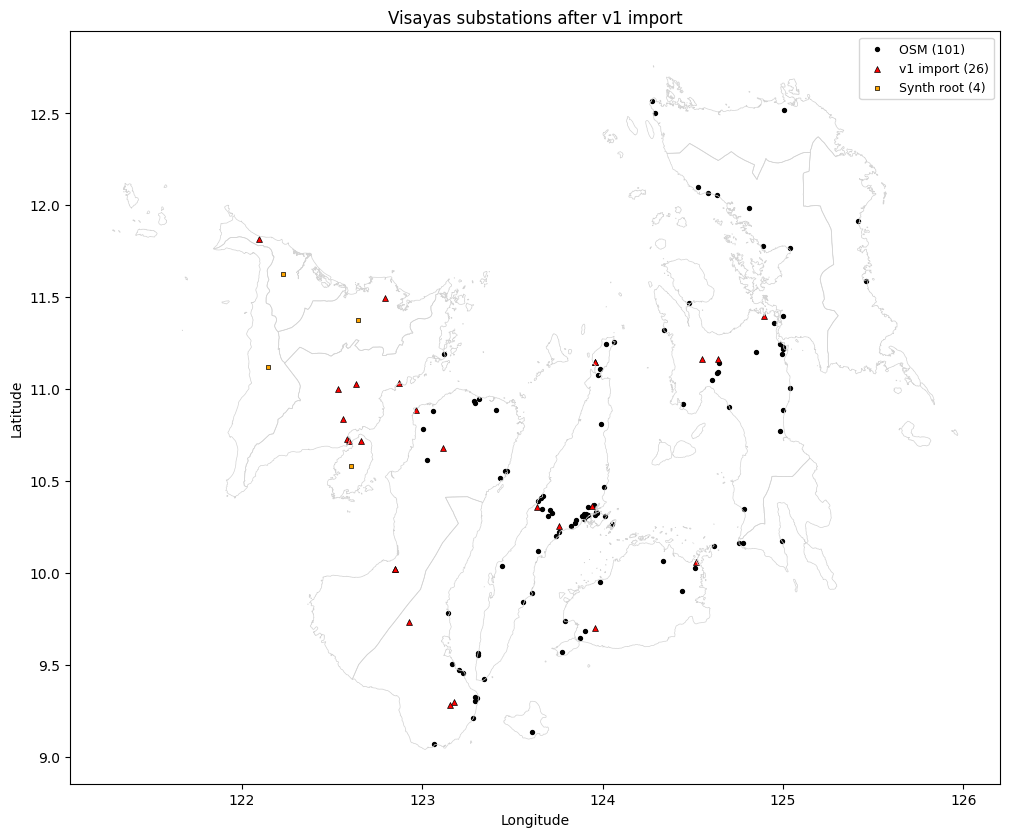

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 10))
provinces.boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)

sub_classes = ['substation', 'substation_synth', 'generator', 'hvdc', 'bess']
subs_only = buses_out[buses_out['bus_type'].isin(sub_classes)]
subs_gdf = gpd.GeoDataFrame(
    subs_only, geometry=gpd.points_from_xy(subs_only['lon'], subs_only['lat']), crs=WGS)

osm_subs = subs_gdf[subs_gdf['data_source'] == 'osm']
v1_subs  = subs_gdf[subs_gdf['data_source'] == 'v1_curated']
synth    = subs_gdf[subs_gdf['data_source'] == 'synthetic']

osm_subs.plot(ax=ax, color='black', markersize=8, label=f'OSM ({len(osm_subs)})')
v1_subs.plot(ax=ax, color='red', markersize=18, marker='^',
             label=f'v1 import ({len(v1_subs)})', edgecolor='black', linewidth=0.5)
synth.plot(ax=ax, color='orange', markersize=12, marker='s',
           label=f'Synth root ({len(synth)})', edgecolor='black', linewidth=0.5)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Visayas substations after v1 import')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')